In [63]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics
from atomica_rna_mlp import compute_binary_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

sns.set_context("notebook")
custom_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', '#806080', '#00C4C7', '#059094']
xtick_map = {
    'RNAGlib': 'RNAglib',
    'grnade': 'gRNAde',
    'rinalmo': 'RiNALMo',
    'rnafm': 'RNA-FM',
    'rnaernie': 'RNAErnie',
    'atomica': 'ATOMICA',
    'atomica-ensemble': 'ATOMICA\nEnsemble',
    'grnade (ensemble)': 'gRNAde\nEnsemble',
    'rinalmo (ensemble)': 'RiNALMo\nEnsemble',
    'rnaernie (ensemble)': 'RNAErnie\nEnsemble',
    'rnafm (ensemble)': 'RNA-FM\nEnsemble',
    'atomica-rnafm-ensemble': 'ATOMICA\nRNA-FM\nEnsemble',
    'atomica-rnafm': 'ATOMICA RNA-FM',
    'RNAGlib (ensemble)': 'RNAglib\nEnsemble',
}

DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"
MODEL_DIR="/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark"
SAVED_MODEL_DIR="/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/checkpoints/benchmarks"

plt.rcParams.update({"font.size": 14})

## Dataset Sizes

In [14]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

def aligned_identity(seq1: str, seq2: str) -> float:
    """
    Compute sequence identity after global alignment.
    Identity = matches / aligned length (excluding gaps in both).
    """
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if len(alignments) == 0:
        print(seq1, seq2, "no alignment")
        return 0.0
    aln1, aln2, _, _, _ = alignments[0]

    matches = 0
    aligned = 0
    for a, b in zip(aln1, aln2):
        if a == "-" or b == "-":
            continue
        aligned += 1
        if a == b:
            matches += 1

    return matches / aligned if aligned > 0 else 0.0


def max_identity_to_train(test_seqs, train_seqs):
    """
    Compute maximum sequence identity of each test sequence
    to the training set.

    Args:
        test_seqs: dict {id: sequence}
        train_seqs: dict {id: sequence}

    Returns:
        dict {test_id: max_identity}
    """
    results = {}
    for test_id, test_seq in test_seqs.items():
        max_id = 0.0
        for train_seq in train_seqs.values():
            ident = aligned_identity(test_seq, train_seq)
            max_id = max(max_id, ident)
        results[test_id] = max_id
    return results

### RNAGo

RNAGo label_mapping = {"0000353": 0, "0005682": 1, "0005686": 2, "0005688": 3, "0010468": 4}

This is taken from the source code of RNAGo in RNAGlib.

In [15]:
task="RNAGo"
all_df = []
all_label_counts = np.zeros(5)
for split in ["test", "val", "train"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task}/{task}_{split}_processed_RNA.parquet")
    print(split, len(df))
    labels = np.stack(df['label'])
    label_counts = np.sum(labels, axis=0)
    print(split, label_counts)
    all_label_counts += label_counts
    df['split'] = split
    all_df.append(df)
all_df = pd.concat(all_df)
print(all_label_counts)
print(all_label_counts/len(all_df))

test 75
test [ 8.  7. 11.  1. 20.]
val 75
val [32.  3. 10. 27.  5.]
train 349
train [127.  71.  50.  50.  75.]
[167.  81.  71.  78. 100.]
[0.33466934 0.16232465 0.14228457 0.15631263 0.2004008 ]


In [16]:
np.unique(np.stack(all_df['label'].tolist()).sum(axis=1), return_counts=True), len(all_df)

((array([0., 1., 2.]), array([161, 179, 159])), 499)

In [17]:
all_df['json_path'] = all_df['id'].apply(lambda x: f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/RNAGo/dataset/{x}.json")
all_df['go_terms'] = all_df['json_path'].apply(lambda x: json.load(open(x))['graph']['go_terms'])
all_df['sequence'] = all_df['json_path'].apply(lambda x: json.load(open(x))['graph']['seq'])
all_df['sequence_joined'] = all_df['sequence'].apply(lambda x: ''.join(x.values()))

In [18]:
from collections import Counter
Counter(np.concatenate(all_df['go_terms'].tolist()))

Counter({'0000353': 167,
         '0010468': 100,
         '0005682': 81,
         '0005688': 78,
         '0005686': 71,
         '0009113': 58,
         '0000373': 55,
         '0006617': 31,
         '0003824': 26,
         '0006396': 6})

### RNA_Ligand

In [19]:
# 0=LLL, 1 = PAR, 2=8UZ
task="RNA_Ligand"
total_inputs = 0
total_label_counts = []
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task}/{task}_{split}_processed_RNA.parquet")
    print(split, len(df), df["label"].value_counts())
    total_label_counts.append(df["label"].value_counts())
    total_inputs += len(df)


all_label_counts = pd.concat(total_label_counts, axis=0).groupby(level=0).sum()
print(f"All label counts {total_inputs}")
print(all_label_counts)
print("All label counts per input")
print(all_label_counts/total_inputs)

train 203 label
1    137
0     46
2     20
Name: count, dtype: int64
val 43 label
1    29
0    10
2     4
Name: count, dtype: int64
test 44 label
1    29
0    10
2     5
Name: count, dtype: int64
All label counts 290
label
0     66
1    195
2     29
Name: count, dtype: int64
All label counts per input
label
0    0.227586
1    0.672414
2    0.100000
Name: count, dtype: float64


### RNA_Protein

In [20]:
task="RNA_Protein"
total_num_residues = 0
all_pdbs = set()
total_positive_residues = 0
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task}/{task}_{split}_processed_RNA.parquet")
    print(split, len(df), np.concatenate(df["label"]).shape[0], np.concatenate(df["label"]).mean())
    total_num_residues += np.concatenate(df["label"]).shape[0]
    all_pdbs.update(df['id'].unique())
    total_positive_residues += np.concatenate(df["label"]).sum()

print("Total number of residues: ", total_num_residues)
print("Total number of PDB chains: ", len(all_pdbs))
print("Total number of PDBs: ", len(set([x.split('_')[0] for x in all_pdbs])))
print("Positive residue ratio: ", total_positive_residues/total_num_residues)

train 891 52175 0.2673694298035458
val 191 11063 0.2709030100334448
test 190 10851 0.274076122016404
Total number of residues:  74089
Total number of PDB chains:  1272
Total number of PDBs:  1138
Positive residue ratio:  0.2688793208168554


### RNA_Site

In [21]:
task="RNA_Site"
total_num_residues = 0
all_pdbs = set()
total_positive_residues = 0
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task}/{task}_{split}_processed_RNA.parquet")
    print(split, len(df), np.concatenate(df["label"]).shape[0], np.concatenate(df["label"]).mean())
    total_num_residues += np.concatenate(df["label"]).shape[0]
    all_pdbs.update(df['id'].unique())
    total_positive_residues += np.concatenate(df["label"]).sum()

print("Total number of residues: ", total_num_residues)
print("Total number of PDB chains: ", len(all_pdbs))
print("Total number of PDBs: ", len(set([x.split('_')[0] for x in all_pdbs])))
print("Positive residue ratio: ", total_positive_residues/total_num_residues)


train 157 10092 0.07827982560443916
val 34 2162 0.07816836262719704
test 33 2158 0.0783132530120482
Total number of residues:  14412
Total number of PDB chains:  224
Total number of PDBs:  218
Positive residue ratio:  0.07826810990840966


## Plot Results

In [22]:
def process_atomica_rnafm_mlp_results(results_dir: str, val_metric: str) -> pd.DataFrame:
    model_name = os.path.basename(os.path.dirname(results_dir))
    task_name = os.path.basename(results_dir)

    if task_name == "RNA_Ligand_pocket":
        test_true = np.load(f"{DATA_DIR}/RNA_Ligand/RNA_Ligand_test_labels_{model_name}_pocket.npy")
    elif task_name == "RNAGo_subseq":
        test_true = np.load(f"{DATA_DIR}/RNAGo/RNAGo_test_labels_{model_name}_subseq.npy")
    else:
        test_true = np.load(f"{DATA_DIR}/{task_name}/{task_name}_test_labels_{model_name}.npy")

    versions = os.listdir(results_dir)
    if len(versions) != 1:
        raise ValueError(f"Expected 1 version, got {len(versions)}")
    best_version = versions[0]
    
    test_results = []
    ensemble_probs = []
    for seed in os.listdir(os.path.join(results_dir, best_version)):
        test_probs = np.load(os.path.join(results_dir, best_version, seed, "test_probabilities.npy"))

        if task_name.startswith("RNA_Ligand"):
            preds = np.argmax(test_probs, axis=1)
            test_metrics = compute_multiclass_metrics(test_true, preds, y_proba=test_probs)
        elif task_name.startswith("RNAGo"):
            preds = test_probs >= 0.5
            test_metrics = compute_multilabel_metrics(
                test_true, y_pred=preds, y_proba=test_probs
            )
        else:
            preds = test_probs[:, 1] >= 0.5
            test_metrics = compute_binary_metrics(
                test_true, y_pred=preds, y_proba=test_probs
            )
        ensemble_probs.append(test_probs)
        test_metrics = test_metrics.to_dict()
        test_metrics['version'] = best_version
        test_metrics['seed'] = seed
        test_metrics['checkpoint_path'] = os.path.join(results_dir, best_version, seed)
        test_results.append(test_metrics)
    ensemble_probs = np.mean(np.stack(ensemble_probs), axis=0)
    if task_name.startswith("RNA_Ligand"):
        preds = np.argmax(ensemble_probs, axis=1)
        test_metrics = compute_multiclass_metrics(test_true, preds, y_proba=ensemble_probs)
    elif task_name.startswith("RNAGo"):
        preds = ensemble_probs >= 0.5
        test_metrics = compute_multilabel_metrics(test_true, preds, y_proba=ensemble_probs)
    else:
        preds = ensemble_probs[:, 1] >= 0.5
        test_metrics = compute_binary_metrics(
            test_true, y_pred=preds, y_proba=ensemble_probs
        )
    test_metrics = test_metrics.to_dict()
    test_metrics['version'] = 'ensemble'
    test_metrics['seed'] = 'ensemble'
    test_metrics['checkpoint_path'] = 'ensemble'
    test_results.append(test_metrics)
    return pd.DataFrame(test_results)

def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, recompute=False):
    if not recompute and os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        results = pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
        if 'ckpt' in results.columns and model_checkpoint in results['ckpt'].tolist():
            return results
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed_RNA.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1

    atomica_preds_run = []
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds_run.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds_run)
    
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results['ckpt'] = model_checkpoint
    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

In [23]:
def load_rnaglib_baseline(task_name):
    results_dir = f"{DATA_DIR}/rnaglib/{task_name}"
    test_results = []
    ensemble_probs = []
    for seed in os.listdir(results_dir):
        test_probs = np.load(os.path.join(results_dir, seed, "test_probabilities.npy"))
        test_true = np.load(os.path.join(results_dir, seed, "test_labels.npy"))

        if task_name == "RNA_Ligand":
            preds = np.argmax(test_probs, axis=1)
            test_metrics = compute_multiclass_metrics(test_true, preds, y_proba=test_probs)
        elif task_name == "RNAGo":
            preds = test_probs >= 0.5
            test_metrics = compute_multilabel_metrics(
                test_true, y_pred=preds, y_proba=test_probs
            )
        else:
            preds = test_probs >= 0.5
            test_probs = np.stack([1-test_probs, test_probs], axis=1)
            test_metrics = compute_binary_metrics(
                test_true, y_pred=preds, y_proba=test_probs
            )
        ensemble_probs.append(test_probs)
        test_metrics = test_metrics.to_dict()
        test_metrics['seed'] = seed
        test_metrics['version'] = f'seed{seed}'
        test_metrics['checkpoint_path'] = os.path.join(results_dir, seed)
        test_results.append(test_metrics)
    ensemble_probs = np.mean(np.stack(ensemble_probs), axis=0)
    if task_name == "RNA_Ligand":
        preds = np.argmax(ensemble_probs, axis=1)
        test_metrics = compute_multiclass_metrics(test_true, preds, y_proba=ensemble_probs)
    elif task_name == "RNAGo":
        preds = ensemble_probs >= 0.5
        test_metrics = compute_multilabel_metrics(test_true, preds, y_proba=ensemble_probs)
    else:
        preds = ensemble_probs[:, 1] >= 0.5
        test_metrics = compute_binary_metrics(
            test_true, y_pred=preds, y_proba=ensemble_probs
        )
    test_metrics = test_metrics.to_dict()
    test_metrics['seed'] = 'ensemble'
    test_metrics['checkpoint_path'] = 'ensemble'
    test_metrics['version'] = 'ensemble'
    test_results.append(test_metrics)
    df = pd.DataFrame(test_results)
    df['baseline_model'] = 'RNAGlib'
    return df


rnaglib_baselines = {}
for task_name in ["RNA_Ligand","RNA_Site","RNA_Protein","RNAGo"]:
    rnaglib_baselines[task_name] = load_rnaglib_baseline(task_name)

# RNAGo
Not SOTA

In [24]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    if baseline_model != "grnade":
        task_name = "RNAGo_subseq"
    else:
        task_name = "RNAGo"
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNAGo", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines = pd.concat([baselines, rnaglib_baselines['RNAGo']])
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_macro': ['mean', 'std'],
    'auprc_micro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_micro': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_micro': ['mean', 'std'],
    'auprc_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_micro': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

subset_accuracy            f1_macro            f1_micro  \
                               mean       std      mean       std      mean   
baseline_model                                                                
RNAGlib                    0.482667  0.058424  0.291010  0.098903  0.255291   
grnade                     0.342222  0.015396  0.539463  0.023801  0.535536   
rinalmo                    0.888000  0.020221  0.858054  0.010588  0.885230   
rnaernie                   0.738667  0.020221  0.626245  0.026511  0.684060   
rnafm                      0.842667  0.034512  0.728758  0.022533  0.790257   
RNAGlib (ensemble)         0.506667       NaN  0.288889       NaN  0.237288   
grnade (ensemble)          0.360000       NaN  0.541181       NaN  0.541353   
rinalmo (ensemble)         0.866667       NaN  0.846460       NaN  0.866667   
rnaernie (ensemble)        0.720000       NaN  0.607302       NaN  0.673913   
rnafm (ensemble)           0.853333       NaN  0.744986       NaN  0.804348   

                              f1_weighted           auprc_macro            \
                          std        mean       std        mean       std   
baseline_model                                                              
RNAGlib              0.114468    0.222336  0.132449    0.704112  0.045334   
grnade               0.016640    0.645865  0.020376    0.580277  0.034736   
rinalmo              0.018291    0.887143  0.020354    0.989311  0.005710   
rnaernie             0.018764    0.673088  0.027963    0.885360  0.008360   
rnafm                0.028633    0.806414  0.025558    0.986339  0.011120   
RNAGlib (ensemble)        NaN    0.182033       NaN    0.691060       NaN   
grnade (ensemble)         NaN    0.646240       NaN    0.546147       NaN   
rinalmo (ensemble)        NaN    0.867534       NaN    0.992771       NaN   
rnaernie (ensemble)       NaN    0.649983       NaN    0.900953       NaN   
rnafm (ensemble)          NaN    0.817081       NaN    0.989895       NaN   

                    auprc_micro           roc_auc_ovr_macro            \
                           mean       std              mean       std   
baseline_model                                                          
RNAGlib                0.456300  0.084852          0.887770  0.016778   
grnade                 0.355287  0.075310          0.842682  0.005453   
rinalmo                0.940886  0.013161          0.994609  0.003340   
rnaernie               0.745860  0.034175          0.959010  0.007393   
rnafm                  0.884663  0.026553          0.996052  0.004003   
RNAGlib (ensemble)     0.464364       NaN          0.882156       NaN   
grnade (ensemble)      0.318917       NaN          0.840986       NaN   
rinalmo (ensemble)     0.945192       NaN          0.996807       NaN   
rnaernie (ensemble)    0.774557       NaN          0.968540       NaN   
rnafm (ensemble)       0.896380       NaN          0.997648       NaN   

                    roc_auc_ovr_micro            
                                 mean       std  
baseline_model                                   
RNAGlib                      0.857745  0.036232  
grnade                       0.829766  0.004075  
rinalmo                      0.984704  0.006949  
rnaernie                     0.920797  0.021209  
rnafm                        0.973832  0.008213  
RNAGlib (ensemble)           0.857032       NaN  
grnade (ensemble)            0.828360       NaN  
rinalmo (ensemble)           0.987545       NaN  
rnaernie (ensemble)          0.942138       NaN  
rnafm (ensemble)             0.978594       NaN

In [25]:
# imbalanced dataset
task_name = "RNAGo"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    labels = np.stack(df['label'])
    label_counts = np.sum(labels, axis=0)/len(labels)
    print(split, label_counts)

train [0.36389685 0.2034384  0.14326648 0.14326648 0.21489971]
val [0.42666667 0.04       0.13333333 0.36       0.06666667]
test [0.10666667 0.09333333 0.14666667 0.01333333 0.26666667]


In [26]:
test_metrics = []
val_metrics = []

checkpoint_paths = [
    f'{SAVED_MODEL_DIR}/rna_go/seed{seed}/model.ckpt' for seed in range(5)
]

# checkpoint_paths = [
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_35/checkpoint/epoch114_step15755.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_27/checkpoint/epoch362_step50094.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_26/checkpoint/epoch216_step30597.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_32/checkpoint/epoch91_step12696.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models_refined/version_41/checkpoint/epoch120_step16698.pt'
# ]

ensemble_test_prob = None
ensemble_val_prob = None
for checkpoint_path in checkpoint_paths:
    atomica_results_val = get_atomica_results(checkpoint_path, "RNAGo", split="val")
    atomica_results_test = get_atomica_results(checkpoint_path, "RNAGo", split="test")

    # best_f1_threshold = 0.0
    # best_f1_score = 0.0
    # f1_thresholds = np.linspace(0.0, 1.0, 11)
    # for threshold in f1_thresholds:
    #     metrics = compute_multilabel_metrics(
    #         y_true=np.stack(atomica_results_val['label']),
    #         y_proba=np.stack(atomica_results_val['pred_probability']),
    #         threshold=threshold
    #     )
    #     if metrics.f1_weighted > best_f1_score:
    #         best_f1_score = metrics.f1_weighted
    #         best_f1_threshold = threshold
    # atomica_preds = np.stack(atomica_results_test['pred_probability']) > best_f1_threshold

    # print("Best F1 threshold: ", best_f1_threshold)
    best_f1_threshold = 0.5 # for consistency with baselines use 0.5 as threshold
    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_test['label']),
        y_proba=np.stack(atomica_results_test['pred_probability']),
        threshold=best_f1_threshold
    )
    if ensemble_test_prob is None:
        ensemble_test_prob = atomica_results_test['pred_probability']
        ensemble_val_prob = atomica_results_val['pred_probability']
    else:
        ensemble_test_prob += atomica_results_test['pred_probability']
        ensemble_val_prob += atomica_results_val['pred_probability']
    test_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
        'auprc_macro': metrics.auprc_macro,
        'auprc_micro': metrics.auprc_micro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_micro': metrics.roc_auc_ovr_micro,
    })

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        threshold=best_f1_threshold
    )
    val_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
        'auprc_macro': metrics.auprc_macro,
        'auprc_micro': metrics.auprc_micro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_micro': metrics.roc_auc_ovr_micro,
    })

test_metrics = pd.DataFrame(test_metrics)
val_metrics = pd.DataFrame(val_metrics)
test_metrics['split'] = 'atomica'
val_metrics['split'] = 'atomica-val'

# Ensemble the seeds is not useful for this task
ensemble_test_prob = np.stack(ensemble_test_prob) / len(checkpoint_paths)
ensemble_val_prob = np.stack(ensemble_val_prob) / len(checkpoint_paths)

# best_f1_threshold = 0.0
# best_f1_score = 0.0
# f1_thresholds = np.linspace(0.0, 0.5, 6)
# for threshold in f1_thresholds:
#     metrics = compute_multilabel_metrics(
#         y_true=np.stack(atomica_results_val['label']),
#         y_proba=ensemble_val_prob,
#         threshold=threshold
#     )
#     if metrics.f1_weighted > best_f1_score:
#         best_f1_score = metrics.f1_weighted
#         best_f1_threshold = threshold
# print("Best F1 threshold: ", best_f1_threshold)

best_f1_threshold = 0.5 # for consistency with baselines use 0.5 as threshold
ensemble_metrics = compute_multilabel_metrics(
    y_true=np.stack(atomica_results_test['label']),
    y_proba=np.stack(ensemble_test_prob),
    threshold=best_f1_threshold
)
ensemble_metrics = pd.DataFrame({
    'split': ['atomica-ensemble'],
    'subset_accuracy': [ensemble_metrics.subset_accuracy],
    'f1_macro': [ensemble_metrics.f1_macro],
    'f1_micro': [ensemble_metrics.f1_micro],
    'f1_weighted': [ensemble_metrics.f1_weighted],
    'auprc_macro': [ensemble_metrics.auprc_macro],
    'auprc_micro': [ensemble_metrics.auprc_micro],
    'roc_auc_ovr_macro': [ensemble_metrics.roc_auc_ovr_macro],
    'roc_auc_ovr_micro': [ensemble_metrics.roc_auc_ovr_micro],
})

all_metrics = pd.concat([val_metrics,test_metrics, ensemble_metrics])
all_metrics = all_metrics.groupby('split').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_macro': ['mean', 'std'],
    'auprc_micro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_micro': ['mean', 'std'],
})
display(all_metrics)

subset_accuracy            f1_macro            f1_micro  \
                            mean       std      mean       std      mean   
split                                                                      
atomica                 0.688000  0.212624  0.778975  0.155887  0.739517   
atomica-ensemble        0.906667       NaN  0.951429       NaN  0.919540   
atomica-val             0.877333  0.023851  0.901608  0.030754  0.926008   

                           f1_weighted           auprc_macro            \
                       std        mean       std        mean       std   
split                                                                    
atomica           0.159627    0.764346  0.143488    0.961409  0.032545   
atomica-ensemble       NaN    0.915805       NaN    0.992713       NaN   
atomica-val       0.022406    0.925453  0.021866    0.930287  0.047581   

                 auprc_micro           roc_auc_ovr_macro            \
                        mean       std              mean       std   
split                                                                
atomica             0.850347  0.139783          0.978564  0.021413   
atomica-ensemble    0.956810       NaN          0.995636       NaN   
atomica-val         0.947534  0.027379          0.967090  0.026006   

                 roc_auc_ovr_micro            
                              mean       std  
split                                         
atomica                   0.958524  0.035841  
atomica-ensemble          0.988778       NaN  
atomica-val               0.972727  0.025190

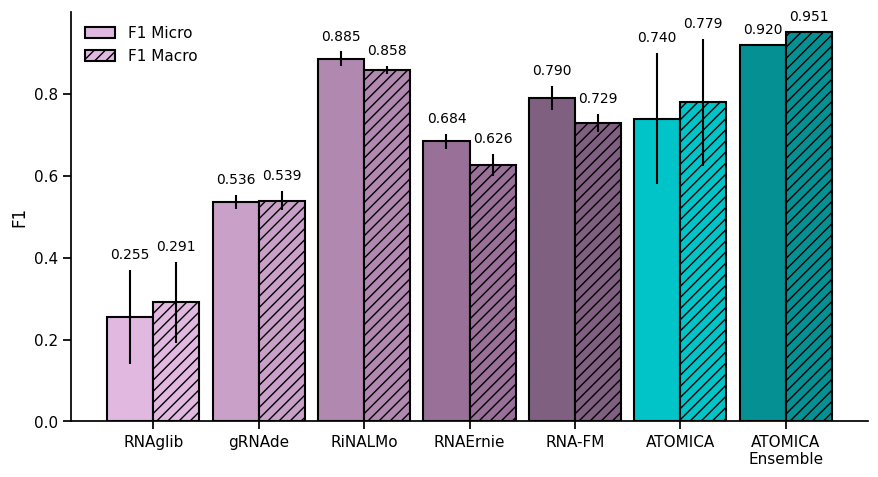

In [27]:
to_plot = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics[~all_metrics.index.str.contains('-val')],
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = to_plot[('f1_micro', 'mean')].values
f1_micro_stds = to_plot[('f1_micro', 'std')].values
f1_macro_means = to_plot[('f1_macro', 'mean')].values
f1_macro_stds = to_plot[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig("figures/rnago_f1_comparison.svg", format='svg')
plt.show()

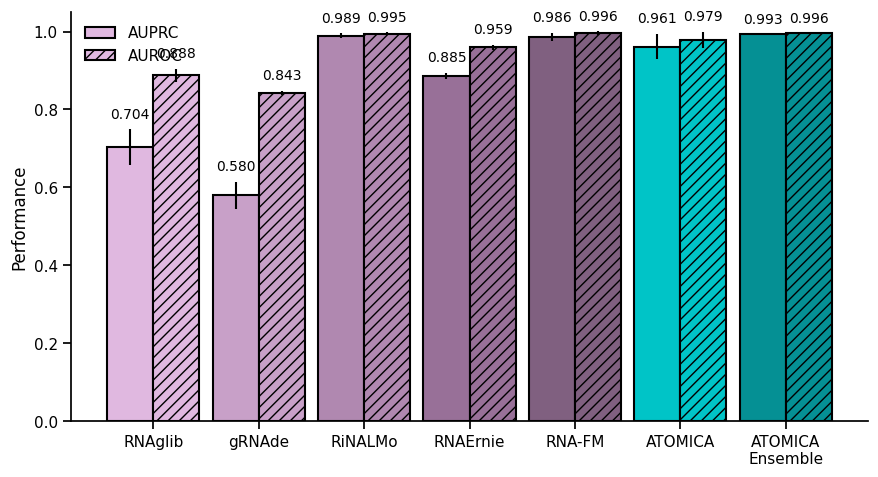

In [28]:
to_plot = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics[~all_metrics.index.str.contains('-val')],
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
auprc_macro_means = to_plot[('auprc_macro', 'mean')].values
auprc_macro_stds = to_plot[('auprc_macro', 'std')].values
auroc_macro_means = to_plot[('roc_auc_ovr_macro', 'mean')].values
auroc_macro_stds = to_plot[('roc_auc_ovr_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(9, 5))

# Plot bars side by side with no gap (adjacent positions)
# auprc_macro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, auprc_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='AUPRC' if i == 0 else '')
    bars1.append(bar)

# auroc_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, auroc_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='AUROC' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, auprc_macro_means, yerr=auprc_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, auroc_macro_means, yerr=auroc_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = auprc_macro_means[i] + (auprc_macro_stds[i] if not np.isnan(auprc_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{auprc_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = auroc_macro_means[i] + (auroc_macro_stds[i] if not np.isnan(auroc_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{auroc_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('Performance', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig("figures/rnago_auprc_auroc_comparison.svg", format='svg')
plt.show()

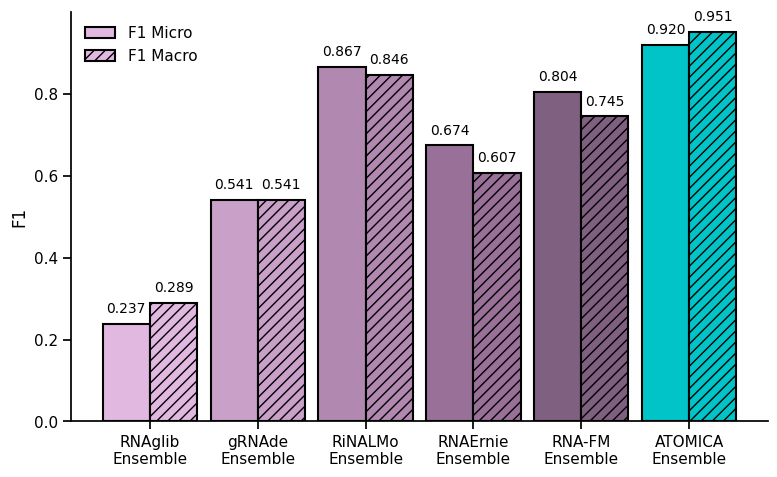

In [29]:
to_plot = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics[all_metrics.index.str.contains('atomica-ensemble')],
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = to_plot[('f1_micro', 'mean')].values
f1_micro_stds = to_plot[('f1_micro', 'std')].values
f1_macro_means = to_plot[('f1_macro', 'mean')].values
f1_macro_stds = to_plot[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig("figures/rnago_ensemble_f1_comparison.svg", format='svg')
plt.show()

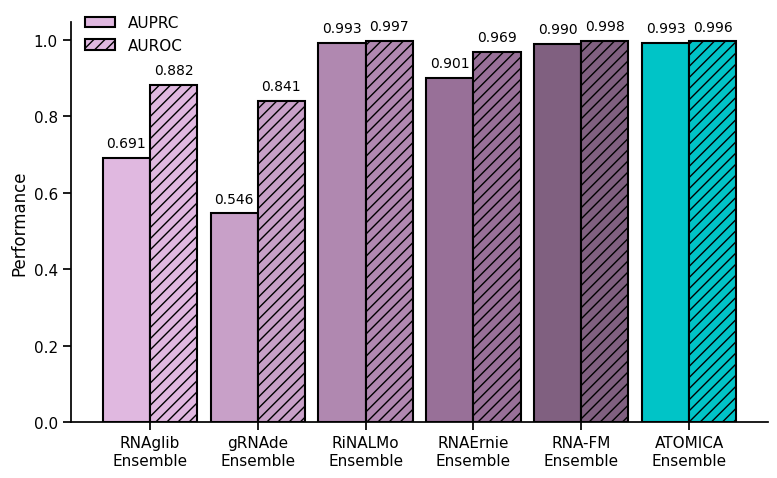

In [30]:
to_plot = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    all_metrics[all_metrics.index.str.contains('atomica-ensemble')],
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
auprc_macro_means = to_plot[('auprc_macro', 'mean')].values
auprc_macro_stds = to_plot[('auprc_macro', 'std')].values
auroc_macro_means = to_plot[('roc_auc_ovr_macro', 'mean')].values
auroc_macro_stds = to_plot[('roc_auc_ovr_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# auprc_macro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, auprc_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='AUPRC' if i == 0 else '')
    bars1.append(bar)

# auroc_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, auroc_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='AUROC' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, auprc_macro_means, yerr=auprc_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, auroc_macro_means, yerr=auroc_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = auprc_macro_means[i] + (auprc_macro_stds[i] if not np.isnan(auprc_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{auprc_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = auroc_macro_means[i] + (auroc_macro_stds[i] if not np.isnan(auroc_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{auroc_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('Performance', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(bbox_to_anchor=(0, 1.05), loc='upper left', frameon=False)
sns.despine()

# ax.get_legend().remove()

plt.tight_layout()
plt.savefig("figures/rnago_ensemble_auprc_auroc_comparison.svg", format='svg')
plt.show()

# RNA Ligand

In [64]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    if baseline_model != "grnade":
        task_name = "RNA_Ligand_pocket"
    else:
        task_name = "RNA_Ligand"
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/{task_name}", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines = pd.concat([baselines, rnaglib_baselines['RNA_Ligand']])
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
 'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_ovr_weighted': ['mean', 'std'],
    'auprc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_weighted': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
 'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_ovr_weighted': ['mean', 'std'],
    'auprc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_weighted': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

accuracy           balanced_accuracy            f1_macro  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
RNAGlib              0.659091  0.000000          0.333333  0.000000  0.264840   
grnade               0.645455  0.041286          0.387816  0.046510  0.380701   
rinalmo              0.700000  0.051826          0.506897  0.066064  0.457256   
rnaernie             0.590909  0.016071          0.451724  0.030116  0.394198   
rnafm                0.572727  0.029633          0.407586  0.084083  0.355336   
RNAGlib (ensemble)   0.659091       NaN          0.333333       NaN  0.264840   
grnade (ensemble)    0.681818       NaN          0.388506       NaN  0.369231   
rinalmo (ensemble)   0.727273       NaN          0.520690       NaN  0.476930   
rnaernie (ensemble)  0.636364       NaN          0.496552       NaN  0.428453   
rnafm (ensemble)     0.590909       NaN          0.451724       NaN  0.394549   

                               f1_micro           f1_weighted            \
                          std      mean       std        mean       std   
baseline_model                                                            
RNAGlib              0.000000  0.659091  0.000000    0.523661  0.000000   
grnade               0.075999  0.645455  0.041286    0.579907  0.042757   
rinalmo              0.047892  0.700000  0.051826    0.669296  0.054105   
rnaernie             0.016358  0.590909  0.016071    0.585433  0.014898   
rnafm                0.071708  0.572727  0.029633    0.551235  0.055053   
RNAGlib (ensemble)        NaN  0.659091       NaN    0.523661       NaN   
grnade (ensemble)         NaN  0.681818       NaN    0.597203       NaN   
rinalmo (ensemble)        NaN  0.727273       NaN    0.691127       NaN   
rnaernie (ensemble)       NaN  0.636364       NaN    0.624295       NaN   
rnafm (ensemble)          NaN  0.590909       NaN    0.578616       NaN   

                    auprc_ovr_weighted           auprc_ovr_macro            \
                                  mean       std            mean       std   
baseline_model                                                               
RNAGlib                       0.486011  0.023012        0.359719  0.029579   
grnade                        0.513154  0.025046        0.397649  0.035541   
rinalmo                       0.747722  0.031351        0.551166  0.031770   
rnaernie                      0.705120  0.031019        0.522496  0.046054   
rnafm                         0.676488  0.011286        0.476286  0.012839   
RNAGlib (ensemble)            0.504813       NaN        0.383403       NaN   
grnade (ensemble)             0.528114       NaN        0.434430       NaN   
rinalmo (ensemble)            0.779270       NaN        0.579913       NaN   
rnaernie (ensemble)           0.725607       NaN        0.543888       NaN   
rnafm (ensemble)              0.677356       NaN        0.472069       NaN   

                    roc_auc_ovr_macro           roc_auc_ovr_weighted            
                                 mean       std                 mean       std  
baseline_model                                                                  
RNAGlib                      0.412814  0.023926             0.426248  0.023678  
grnade                       0.447895  0.034080             0.447870  0.048203  
rinalmo                      0.761240  0.033692             0.804676  0.041392  
rnaernie                     0.714791  0.025917             0.740110  0.023779  
rnafm                        0.681768  0.028627             0.698392  0.026922  
RNAGlib (ensemble)           0.430787       NaN             0.446435       NaN  
grnade (ensemble)            0.448675       NaN             0.444927       NaN  
rinalmo (ensemble)           0.796616       NaN             0.847998       NaN  
rnaernie (ensemble)          0.741346       NaN             0.754679       NaN  
rnaf

In [65]:
task_name = "RNA_Ligand"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    label_counts = df['label'].value_counts()
    label_sample_probs = 1/label_counts
    print(split, label_counts, (len(df)-label_counts)/label_counts)

train label
1    137
0     46
2     20
Name: count, dtype: int64 label
1    0.481752
0    3.413043
2    9.150000
Name: count, dtype: float64
val label
1    29
0    10
2     4
Name: count, dtype: int64 label
1    0.482759
0    3.300000
2    9.750000
Name: count, dtype: float64
test label
1    29
0    10
2     5
Name: count, dtype: int64 label
1    0.517241
0    3.400000
2    7.800000
Name: count, dtype: float64


In [66]:
# best checkpoints at < 400 epochs
model_checkpoints = [
    f'{SAVED_MODEL_DIR}/rna_ligand/atomica/seed{seed}/model.ckpt' for seed in range(5)
]

# model_checkpoints = [
#  f'{MODEL_DIR}/RNA_Ligand/models/version_109/checkpoint/epoch383_step15744.pt',
#  f'{MODEL_DIR}/RNA_Ligand/models/version_117/checkpoint/epoch318_step13079.pt',
#  f'{MODEL_DIR}/RNA_Ligand/models/version_108/checkpoint/epoch399_step16400.pt',
#  f'{MODEL_DIR}/RNA_Ligand/models/version_118/checkpoint/epoch334_step13735.pt',
#  f'{MODEL_DIR}/RNA_Ligand/models/version_120/checkpoint/epoch371_step15252.pt'
# ]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Ligand", split="val", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_pred=np.stack(atomica_results_val['pred']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        labels=[0,1,2]
    )
    # ensemble by mean ##############
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    ##############

    # ensemble by max ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability'])
    # else:
    #     new_prob = np.stack(atomica_results['pred_probability'])
    #     assert ensemble_prob.shape == new_prob.shape, f"{ensemble_prob.shape} != {new_prob.shape}"
    #     ensemble_prob = np.stack([ensemble_prob, new_prob], axis=0)
    #     ensemble_prob = np.max(ensemble_prob, axis=0)
    ##############

    # # ensemble by vote ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)
    # else:
    #     ensemble_prob = np.concatenate([ensemble_prob, np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)], axis=1)
    ##############

    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

# ensemble by mean ##############
ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
#############

# ensemble by max ##############
# ensemble_prob = np.stack(ensemble_prob) / np.sum(ensemble_prob, axis=1, keepdims=True)
##############

# ensemble by vote ##############
# ensemble_prob_ = np.zeros((ensemble_prob.shape[0], 3))
# ensemble_prob, ensemble_counts = np.unique(ensemble_prob, axis=1, return_counts=True)
# ensemble_prob_[np.arange(ensemble_prob_.shape[0])[:, None], ensemble_prob] = ensemble_counts
# ensemble_prob = ensemble_prob_ / np.sum(ensemble_prob_, axis=1, keepdims=True)
##############

ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)

metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': ensemble_metrics.accuracy,
    'balanced_accuracy': ensemble_metrics.balanced_accuracy,
    'f1_macro': ensemble_metrics.f1_macro,
    'f1_micro': ensemble_metrics.f1_micro,
    'f1_weighted': ensemble_metrics.f1_weighted,
    'auprc_ovr_weighted': ensemble_metrics.auprc_ovr_weighted,
    'auprc_ovr_macro': ensemble_metrics.auprc_ovr_macro,
    'roc_auc_ovr_macro': ensemble_metrics.roc_auc_ovr_macro,
    'roc_auc_ovr_weighted': ensemble_metrics.roc_auc_ovr_weighted,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)

atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_ovr_weighted': ['mean', 'std'],
    'auprc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_weighted': ['mean', 'std'],
})

# for metric in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_micro', 'f1_weighted']:
#     atomica_metrics.loc['atomica-ensemble', (metric, 'std')] = atomica_metrics.loc['atomica', (metric, 'std')] 

display(atomica_metrics)

accuracy           balanced_accuracy            f1_macro  \
                      mean       std              mean       std      mean   
model                                                                        
atomica           0.850000  0.052322          0.783678  0.115888  0.791221   
atomica-ensemble  0.795455       NaN          0.677011       NaN  0.720521   
atomica-val       0.902326  0.019457          0.773103  0.025490  0.816459   

                            f1_micro           f1_weighted            \
                       std      mean       std        mean       std   
model                                                                  
atomica           0.101454  0.850000  0.052322    0.846196  0.058086   
atomica-ensemble       NaN  0.795455       NaN    0.788302       NaN   
atomica-val       0.015121  0.902326  0.019457    0.896458  0.019220   

                 auprc_ovr_weighted           auprc_ovr_macro            \
                               mean       std            mean       std   
model                                                                     
atomica                    0.915822  0.030604        0.875082  0.050383   
atomica-ensemble           0.943639       NaN        0.927208       NaN   
atomica-val                0.909626  0.025365        0.807316  0.036376   

                 roc_auc_ovr_macro           roc_auc_ovr_weighted            
                              mean       std                 mean       std  
model                                                                        
atomica                   0.947030  0.017899             0.945416  0.015244  
atomica-ensemble          0.966937       NaN             0.962567       NaN  
atomica-val               0.925627  0.017247             0.952622  0.014541

In [67]:
# best checkpoints at < 400 epochs
model_checkpoints_no_RNAL_in_pretrain = [
    f'{SAVED_MODEL_DIR}/rna_ligand/atomica_no_RNAL_in_pretrain/seed{seed}/model.pt' for seed in range(5)
]

# no_RNAL_checkpoints = [
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_281/checkpoint/epoch372_step15293.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_280/checkpoint/epoch360_step14801.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_278/checkpoint/epoch378_step15539.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_279/checkpoint/epoch363_step15652.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_276/checkpoint/epoch201_step8484.ckpt'
# ]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints_no_RNAL_in_pretrain:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    
    metrics_dict = {
        'model': 'atomica-no-RNAL',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Ligand", split="val", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_pred=np.stack(atomica_results_val['pred']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        labels=[0,1,2]
    )
    # ensemble by mean ##############
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    ##############

    # ensemble by max ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability'])
    # else:
    #     new_prob = np.stack(atomica_results['pred_probability'])
    #     assert ensemble_prob.shape == new_prob.shape, f"{ensemble_prob.shape} != {new_prob.shape}"
    #     ensemble_prob = np.stack([ensemble_prob, new_prob], axis=0)
    #     ensemble_prob = np.max(ensemble_prob, axis=0)
    ##############

    # # ensemble by vote ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)
    # else:
    #     ensemble_prob = np.concatenate([ensemble_prob, np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)], axis=1)
    ##############

    metrics_dict = {
        'model': 'atomica-no-RNAL-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

# ensemble by mean ##############
ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
#############

# ensemble by max ##############
# ensemble_prob = np.stack(ensemble_prob) / np.sum(ensemble_prob, axis=1, keepdims=True)
##############

# ensemble by vote ##############
# ensemble_prob_ = np.zeros((ensemble_prob.shape[0], 3))
# ensemble_prob, ensemble_counts = np.unique(ensemble_prob, axis=1, return_counts=True)
# ensemble_prob_[np.arange(ensemble_prob_.shape[0])[:, None], ensemble_prob] = ensemble_counts
# ensemble_prob = ensemble_prob_ / np.sum(ensemble_prob_, axis=1, keepdims=True)
##############

ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)

metrics_dict = {
    'model': 'atomica-no-RNAL-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': ensemble_metrics.accuracy,
    'balanced_accuracy': ensemble_metrics.balanced_accuracy,
    'f1_macro': ensemble_metrics.f1_macro,
    'f1_micro': ensemble_metrics.f1_micro,
    'f1_weighted': ensemble_metrics.f1_weighted,
    'auprc_ovr_weighted': ensemble_metrics.auprc_ovr_weighted,
    'auprc_ovr_macro': ensemble_metrics.auprc_ovr_macro,
    'roc_auc_ovr_macro': ensemble_metrics.roc_auc_ovr_macro,
    'roc_auc_ovr_weighted': ensemble_metrics.roc_auc_ovr_weighted,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)

atomica_metrics_no_RNAL = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_ovr_weighted': ['mean', 'std'],
    'auprc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_weighted': ['mean', 'std'],
})

# for metric in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_micro', 'f1_weighted']:
#     atomica_metrics.loc['atomica-ensemble', (metric, 'std')] = atomica_metrics.loc['atomica', (metric, 'std')] 

atomica_metrics = pd.concat([atomica_metrics, atomica_metrics_no_RNAL])
display(atomica_metrics)

accuracy           balanced_accuracy            \
                              mean       std              mean       std   
model                                                                      
atomica                   0.850000  0.052322          0.783678  0.115888   
atomica-ensemble          0.795455       NaN          0.677011       NaN   
atomica-val               0.902326  0.019457          0.773103  0.025490   
atomica-no-RNAL           0.722727  0.033710          0.560230  0.096379   
atomica-no-RNAL-ensemble  0.750000       NaN          0.609195       NaN   
atomica-no-RNAL-val       0.739535  0.095036          0.637701  0.062094   

                          f1_macro            f1_micro           f1_weighted  \
                              mean       std      mean       std        mean   
model                                                                          
atomica                   0.791221  0.101454  0.850000  0.052322    0.846196   
atomica-ensemble          0.720521       NaN  0.795455       NaN    0.788302   
atomica-val               0.816459  0.015121  0.902326  0.019457    0.896458   
atomica-no-RNAL           0.526261  0.090471  0.722727  0.033710    0.705145   
atomica-no-RNAL-ensemble  0.601954       NaN  0.750000       NaN    0.742674   
atomica-no-RNAL-val       0.632215  0.088503  0.739535  0.095036    0.736558   

                                   auprc_ovr_weighted            \
                               std               mean       std   
model                                                             
atomica                   0.058086           0.915822  0.030604   
atomica-ensemble               NaN           0.943639       NaN   
atomica-val               0.019220           0.909626  0.025365   
atomica-no-RNAL           0.031141           0.784943  0.053802   
atomica-no-RNAL-ensemble       NaN           0.836956       NaN   
atomica-no-RNAL-val       0.078123           0.802376  0.071974   

                         auprc_ovr_macro           roc_auc_ovr_macro  \
                                    mean       std              mean   
model                                                                  
atomica                         0.875082  0.050383          0.947030   
atomica-ensemble                0.927208       NaN          0.966937   
atomica-val                     0.807316  0.036376          0.925627   
atomica-no-RNAL                 0.625686  0.116900          0.728804   
atomica-no-RNAL-ensemble        0.691815       NaN          0.791414   
atomica-no-RNAL-val             0.667507  0.078963          0.777632   

                                   roc_auc_ovr_weighted            
                               std                 mean       std  
model                                                              
atomica                   0.017899             0.945416  0.015244  
atomica-ensemble               NaN             0.962567       NaN  
atomica-val               0.017247             0.952622  0.014541  
atomica-no-RNAL           0.138194             0.821757  0.073432  
atomica-no-RNAL-ensemble       NaN             0.883254       NaN  
atomica-no-RNAL-val       0.061096             0.820115  0.098900

ATOMICA RNA-FM joint model

In [68]:
# Could aggregate by taking the max over the ensemble, but this results in 1.00 accuracy which idk??
# atomica_rnafm_ckpts = [
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_226/checkpoint/epoch296_step12177.pt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_233/checkpoint/epoch200_step8241.pt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_246/checkpoint/epoch170_step7353.pt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_257/checkpoint/epoch179_step7560.pt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_256/checkpoint/epoch190_step7831.pt'
# ]

atomica_rnafm_ckpts = [
    f'{SAVED_MODEL_DIR}/rna_ligand/atomica_rnafm/seed{seed}/model.ckpt' for seed in range(5)
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in atomica_rnafm_ckpts:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    
    metrics_dict = {
        'model': 'atomica-rnafm',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Ligand", split="val", recompute=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_pred=np.stack(atomica_results_val['pred']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        labels=[0,1,2]
    )
    # ensemble by mean ##############
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    ##############

    # ensemble by max ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability'])
    # else:
    #     new_prob = np.stack(atomica_results['pred_probability'])
    #     assert ensemble_prob.shape == new_prob.shape, f"{ensemble_prob.shape} != {new_prob.shape}"
    #     ensemble_prob = np.stack([ensemble_prob, new_prob], axis=0)
    #     ensemble_prob = np.max(ensemble_prob, axis=0)
    ##############

    # # ensemble by vote ##############
    # if ensemble_prob is None:
    #     ensemble_prob = np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)
    # else:
    #     ensemble_prob = np.concatenate([ensemble_prob, np.stack(atomica_results['pred_probability']).argmax(axis=1, keepdims=True)], axis=1)
    ##############

    metrics_dict = {
        'model': 'atomica-rnafm-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
        'auprc_ovr_weighted': metrics.auprc_ovr_weighted,
        'auprc_ovr_macro': metrics.auprc_ovr_macro,
        'roc_auc_ovr_macro': metrics.roc_auc_ovr_macro,
        'roc_auc_ovr_weighted': metrics.roc_auc_ovr_weighted,
    }
    all_metrics.append(metrics_dict)

# ensemble by mean ##############
ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
##############

# ensemble by max ##############
# ensemble_prob = np.stack(ensemble_prob) / np.sum(ensemble_prob, axis=1, keepdims=True)
##############

# ensemble by vote ##############
# ensemble_prob_ = np.zeros((ensemble_prob.shape[0], 3))
# ensemble_prob, ensemble_counts = np.unique(ensemble_prob, axis=1, return_counts=True)
# ensemble_prob_[np.arange(ensemble_prob_.shape[0])[:, None], ensemble_prob] = ensemble_counts
# ensemble_prob = ensemble_prob_ / np.sum(ensemble_prob_, axis=1, keepdims=True)
##############

ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)

metrics_dict = {
    'model': 'atomica-rnafm-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': ensemble_metrics.accuracy,
    'balanced_accuracy': ensemble_metrics.balanced_accuracy,
    'f1_macro': ensemble_metrics.f1_macro,
    'f1_micro': ensemble_metrics.f1_micro,
    'f1_weighted': ensemble_metrics.f1_weighted,
    'auprc_ovr_weighted': ensemble_metrics.auprc_ovr_weighted,
    'auprc_ovr_macro': ensemble_metrics.auprc_ovr_macro,
    'roc_auc_ovr_macro': ensemble_metrics.roc_auc_ovr_macro,
    'roc_auc_ovr_weighted': ensemble_metrics.roc_auc_ovr_weighted,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)

atomica_rnafm_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
    'auprc_ovr_weighted': ['mean', 'std'],
    'auprc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_macro': ['mean', 'std'],
    'roc_auc_ovr_weighted': ['mean', 'std'],
})

# for metric in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_micro', 'f1_weighted']:
#     atomica_metrics.loc['atomica-ensemble', (metric, 'std')] = atomica_metrics.loc['atomica', (metric, 'std')] 

atomica_metrics_joint = pd.concat([atomica_metrics, atomica_rnafm_metrics])
display(atomica_metrics_joint)


accuracy           balanced_accuracy            \
                              mean       std              mean       std   
model                                                                      
atomica                   0.850000  0.052322          0.783678  0.115888   
atomica-ensemble          0.795455       NaN          0.677011       NaN   
atomica-val               0.902326  0.019457          0.773103  0.025490   
atomica-no-RNAL           0.722727  0.033710          0.560230  0.096379   
atomica-no-RNAL-ensemble  0.750000       NaN          0.609195       NaN   
atomica-no-RNAL-val       0.739535  0.095036          0.637701  0.062094   
atomica-rnafm             0.959091  0.019015          0.974943  0.009352   
atomica-rnafm-ensemble    0.977273       NaN          0.988506       NaN   
atomica-rnafm-val         0.976744  0.000000          0.984138  0.009767   

                          f1_macro            f1_micro           f1_weighted  \
                              mean       std      mean       std        mean   
model                                                                          
atomica                   0.791221  0.101454  0.850000  0.052322    0.846196   
atomica-ensemble          0.720521       NaN  0.795455       NaN    0.788302   
atomica-val               0.816459  0.015121  0.902326  0.019457    0.896458   
atomica-no-RNAL           0.526261  0.090471  0.722727  0.033710    0.705145   
atomica-no-RNAL-ensemble  0.601954       NaN  0.750000       NaN    0.742674   
atomica-no-RNAL-val       0.632215  0.088503  0.739535  0.095036    0.736558   
atomica-rnafm             0.945012  0.031773  0.959091  0.019015    0.961470   
atomica-rnafm-ensemble    0.963849       NaN  0.977273       NaN    0.978106   
atomica-rnafm-val         0.977985  0.000659  0.976744  0.000000    0.976941   

                                   auprc_ovr_weighted            \
                               std               mean       std   
model                                                             
atomica                   0.058086           0.915822  0.030604   
atomica-ensemble               NaN           0.943639       NaN   
atomica-val               0.019220           0.909626  0.025365   
atomica-no-RNAL           0.031141           0.784943  0.053802   
atomica-no-RNAL-ensemble       NaN           0.836956       NaN   
atomica-no-RNAL-val       0.078123           0.802376  0.071974   
atomica-rnafm             0.016492           0.992188  0.008539   
atomica-rnafm-ensemble         NaN           1.000000       NaN   
atomica-rnafm-val         0.000342           0.996186  0.001437   

                         auprc_ovr_macro           roc_auc_ovr_macro  \
                                    mean       std              mean   
model                                                                  
atomica                         0.875082  0.050383          0.947030   
atomica-ensemble                0.927208       NaN          0.966937   
atomica-val                     0.807316  0.036376          0.925627   
atomica-no-RNAL                 0.625686  0.116900          0.728804   
atomica-no-RNAL-ensemble        0.691815       NaN          0.791414   
atomica-no-RNAL-val             0.667507  0.078963          0.777632   
atomica-rnafm                   0.981389  0.025703          0.996219   
atomica-rnafm-ensemble          1.000000       NaN          1.000000   
atomica-rnafm-val               0.995916  0.002464          0.997146   

                                   roc_auc_ovr_weighted            
                               std                 mean       std  
model                                                              
atomica                   0.017899             0.945416  0.015244  
atomica-ensemble               NaN             0.962567       NaN  
atomica-val               0.017247             0.952622  0.014541  
atomica-no-RNAL           0.138194             0.821757  0.073432  
atomic

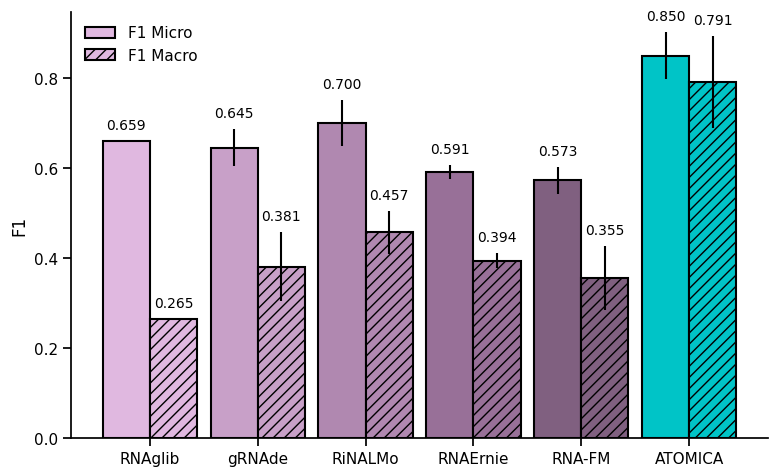

In [69]:
results = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('val')) & (~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('ensemble'))]

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = results[('f1_micro', 'mean')].values
f1_micro_stds = results[('f1_micro', 'std')].values
f1_macro_means = results[('f1_macro', 'mean')].values
f1_macro_stds = results[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.savefig("figures/rna_ligand_f1_comparison.svg", format='svg')
plt.tight_layout()
plt.show()

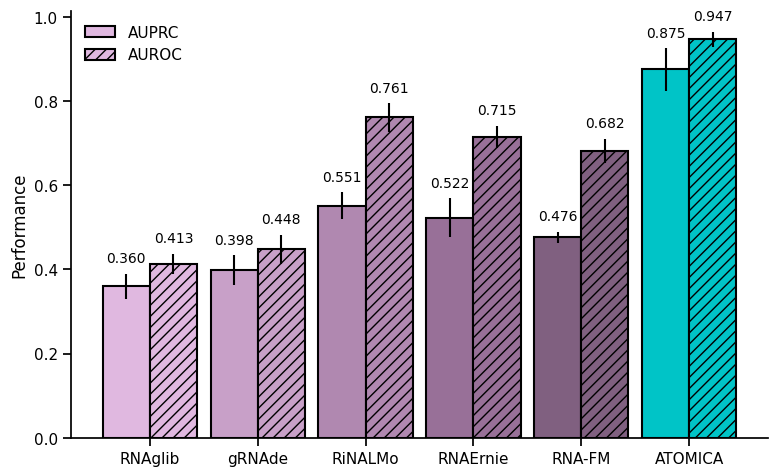

In [70]:
results = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('val')) & (~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('ensemble'))]

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
roc_auc_ovr_macro_means = results[('roc_auc_ovr_macro', 'mean')].values
roc_auc_ovr_macro_stds = results[('roc_auc_ovr_macro', 'std')].values
auprc_ovr_macro_means = results[('auprc_ovr_macro', 'mean')].values
auprc_ovr_macro_stds = results[('auprc_ovr_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# auprc_ovr_macro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, auprc_ovr_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='AUPRC' if i == 0 else '')
    bars1.append(bar)

# roc_auc_ovr_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, roc_auc_ovr_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='AUROC' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, auprc_ovr_macro_means, yerr=auprc_ovr_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, roc_auc_ovr_macro_means, yerr=roc_auc_ovr_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Macro label
    y_pos_macro = auprc_ovr_macro_means[i] + (auprc_ovr_macro_stds[i] if not np.isnan(auprc_ovr_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_macro, f'{auprc_ovr_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Micro label
    y_pos_micro = roc_auc_ovr_macro_means[i] + (roc_auc_ovr_macro_stds[i] if not np.isnan(roc_auc_ovr_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_micro, f'{roc_auc_ovr_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    

# Customize the plot
ax.set_ylabel('Performance', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.savefig("figures/rna_ligand_auprc_comparison.svg", format='svg')
plt.tight_layout()
plt.show()

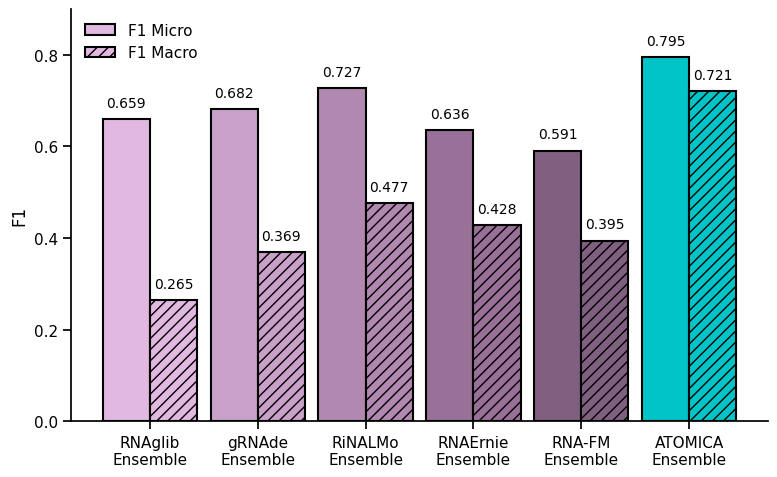

In [74]:
results = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('val')) & (~results['model'].str.contains('RNAL'))]

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = results[('f1_micro', 'mean')].values
f1_micro_stds = results[('f1_micro', 'std')].values
f1_macro_means = results[('f1_macro', 'mean')].values
f1_macro_stds = results[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + (f1_micro_stds[i] if not np.isnan(f1_micro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + (f1_macro_stds[i] if not np.isnan(f1_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

from matplotlib.ticker import MultipleLocator
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.set_ylim(0, 0.9)

plt.tight_layout()
plt.savefig("figures/rna_ligand_ensemble_f1_comparison.svg", format='svg')
plt.show()

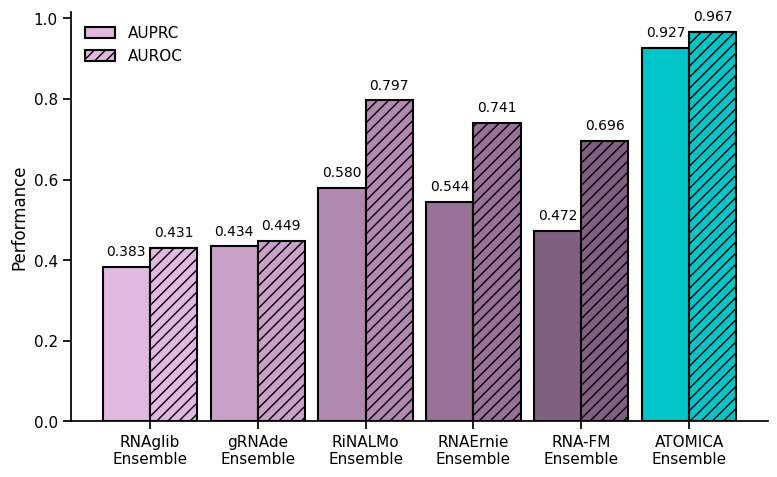

In [45]:
results = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('val')) & (~results['model'].str.contains('RNAL'))]

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
roc_auc_ovr_macro_means = results[('roc_auc_ovr_macro', 'mean')].values
roc_auc_ovr_macro_stds = results[('roc_auc_ovr_macro', 'std')].values
auprc_ovr_macro_means = results[('auprc_ovr_macro', 'mean')].values
auprc_ovr_macro_stds = results[('auprc_ovr_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# auprc_ovr_macro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, auprc_ovr_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='AUPRC' if i == 0 else '')
    bars1.append(bar)

# roc_auc_ovr_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, roc_auc_ovr_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='AUROC' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, auprc_ovr_macro_means, yerr=auprc_ovr_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)
ax.errorbar(x + width/2, roc_auc_ovr_macro_means, yerr=roc_auc_ovr_macro_stds,
            fmt='none', c='black', elinewidth=1.5, capsize=0)

# Add text labels on top of bars
for i in range(n_models):
    # F1 Macro label
    y_pos_macro = auprc_ovr_macro_means[i] + (auprc_ovr_macro_stds[i] if not np.isnan(auprc_ovr_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] - width/2, y_pos_macro, f'{auprc_ovr_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    
    # F1 Micro label
    y_pos_micro = roc_auc_ovr_macro_means[i] + (roc_auc_ovr_macro_stds[i] if not np.isnan(roc_auc_ovr_macro_stds[i]) else 0) + 0.02
    ax.text(x[i] + width/2, y_pos_micro, f'{roc_auc_ovr_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=10)
    

# Customize the plot
ax.set_ylabel('Performance', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best', frameon=False)
sns.despine()

plt.savefig("figures/rna_ligand_ensemble_auprc_comparison.svg", format='svg')
plt.tight_layout()
plt.show()

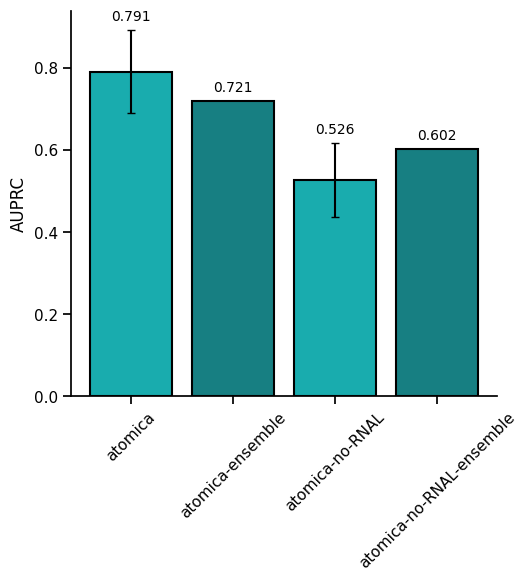

In [47]:
results = atomica_metrics.copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[~results['model'].str.contains('val')]

plt.figure(figsize=(5.5, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('f1_macro', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('f1_macro', 'mean')].values
y_stds = results[('f1_macro', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=3
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.tick_params(axis="x", labelrotation=45)
ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_ligand_no_RNAL_f1_macro_comparison.svg", format='svg')
plt.show()

# RNA-Protein (SOTA)
This also beats RNAGlib 

In [48]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Protein", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines = pd.concat([baselines, rnaglib_baselines['RNA_Protein']])
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
RNAGlib              0.698652  0.024302          0.618512  0.021027  0.683584   
grnade               0.724653  0.000685          0.502562  0.002670  0.681891   
rinalmo              0.698037  0.012098          0.552523  0.003323  0.630808   
rnaernie             0.707649  0.002537          0.563637  0.010524  0.636896   
rnafm                0.676669  0.013013          0.544164  0.011175  0.614155   
RNAGlib (ensemble)   0.733382       NaN          0.633540       NaN  0.708100   
grnade (ensemble)    0.724186       NaN          0.501821       NaN  0.684751   
rinalmo (ensemble)   0.708639       NaN          0.553131       NaN  0.635090   
rnaernie (ensemble)  0.713408       NaN          0.561408       NaN  0.644366   
rnafm (ensemble)     0.683327       NaN          0.542242       NaN  0.620292   

                                  auprc            
                          std      mean       std  
baseline_model                                     
RNAGlib              0.005388  0.424161  0.009737  
grnade               0.004681  0.482840  0.006180  
rinalmo              0.004782  0.379764  0.007097  
rnaernie             0.003624  0.388611  0.009055  
rnafm                0.004071  0.356702  0.003641  
RNAGlib (ensemble)        NaN  0.472629       NaN  
grnade (ensemble)         NaN  0.486296       NaN  
rinalmo (ensemble)        NaN  0.383589       NaN  
rnaernie (ensemble)       NaN  0.398846       NaN  
rnafm (ensemble)          NaN  0.361619       NaN

In [49]:
# Fixed dataset, no PRNA pretrain
# model_checkpoints_no_PRNA = [
#     f"{MODEL_DIR}/RNA_Protein/models/version_11/checkpoint/epoch14_step3240.pt",
#     f"{MODEL_DIR}/RNA_Protein/models/version_12/checkpoint/epoch11_step2592.pt",
#     f"{MODEL_DIR}/RNA_Protein/models/version_13/checkpoint/epoch13_step2982.pt",
#     f"{MODEL_DIR}/RNA_Protein/models/version_14/checkpoint/epoch8_step1926.pt",
#     f"{MODEL_DIR}/RNA_Protein/models/version_15/checkpoint/epoch18_step4123.pt",
# ]

# model_checkpoints = [
#     f'{MODEL_DIR}/RNA_Protein/models/version_18/checkpoint/epoch15_step3408.pt',
#     f'{MODEL_DIR}/RNA_Protein/models/version_16/checkpoint/epoch12_step2782.pt',
#     f'{MODEL_DIR}/RNA_Protein/models/version_17/checkpoint/epoch7_step1728.pt',
#     f'{MODEL_DIR}/RNA_Protein/models/version_20/checkpoint/epoch18_step4104.pt',
#     f'{MODEL_DIR}/RNA_Protein/models/version_19/checkpoint/epoch7_step1736.pt',
# ]

model_checkpoints_no_PRNA = [
    f'{SAVED_MODEL_DIR}/rna_protein/atomica_no_PRNA_in_pretrain/seed{seed}/model.ckpt' for seed in range(5)
]

model_checkpoints = [
    f'{SAVED_MODEL_DIR}/rna_protein/atomica/seed{seed}/model.ckpt' for seed in range(5)
]

all_metrics = []
ensemble_prob = None
ensemble_prob_val = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Protein", split="val")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
        ensemble_prob_val = atomica_results_val['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
        ensemble_prob_val += atomica_results_val['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results_val['label'], atomica_results_val['pred_probability'])
    auprc_val = auc(recall, precision)
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
        'val_auprc': auprc_val,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_PRNA = None
for model_checkpoint in model_checkpoints_no_PRNA:
    atomica_results_no_PRNA = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    if ensemble_prob_no_PRNA is None:
        ensemble_prob_no_PRNA = atomica_results_no_PRNA['pred_probability']
    else:
        ensemble_prob_no_PRNA += atomica_results_no_PRNA['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-PRNA',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_PRNA['label'] == atomica_results_no_PRNA['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], atomica_results_no_PRNA['pred_probability']),
        'auprc': auprc,
        'val_auprc': auprc_val,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_PRNA = np.stack(ensemble_prob_no_PRNA) / len(model_checkpoints_no_PRNA)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results_val['label'], (ensemble_prob_val >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = ensemble_prob > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_PRNA = ensemble_prob_no_PRNA > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA)
auprc_no_PRNA = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-PRNA',
    'checkpoint_path': 'ensemble-no-PRNA',
    'accuracy': np.mean(atomica_results_no_PRNA['label'] == ensemble_pred_no_PRNA),
    'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA),
    'auprc': auprc_no_PRNA,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

display(atomica_metrics)

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.749977  0.022051  0.747571  0.007338  0.567653   
atomica-ensemble          0.725924       NaN  0.774167       NaN  0.603943   
atomica-ensemble-no-PRNA  0.725924       NaN  0.762443       NaN  0.604166   
atomica-no-PRNA           0.760962  0.019654  0.742432  0.007631  0.561472   

                                    
                               std  
model                               
atomica                   0.005575  
atomica-ensemble               NaN  
atomica-ensemble-no-PRNA       NaN  
atomica-no-PRNA           0.000000

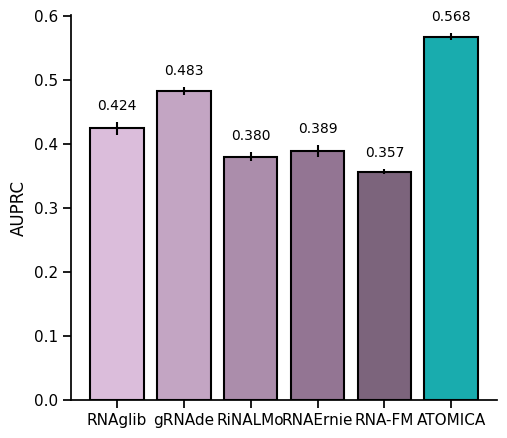

In [50]:
results = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('PRNA')) & (~results['model'].str.contains('-val'))]

plt.figure(figsize=(5.5, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_protein_auprc_comparison.svg", format='svg')
plt.show()

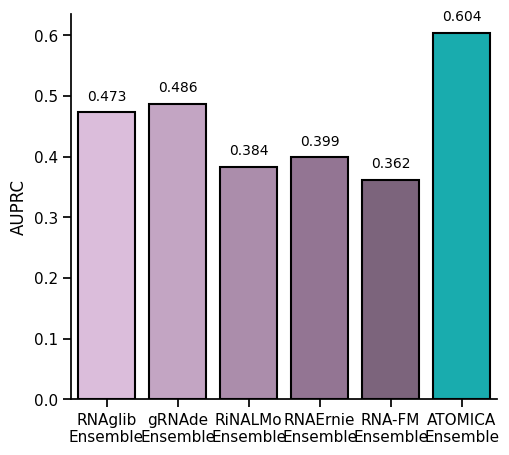

In [51]:
results = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('PRNA')) & (~results['model'].str.contains('-val'))]

plt.figure(figsize=(5.5, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_protein_ensemble_auprc_comparison.svg", format='svg')
plt.show()

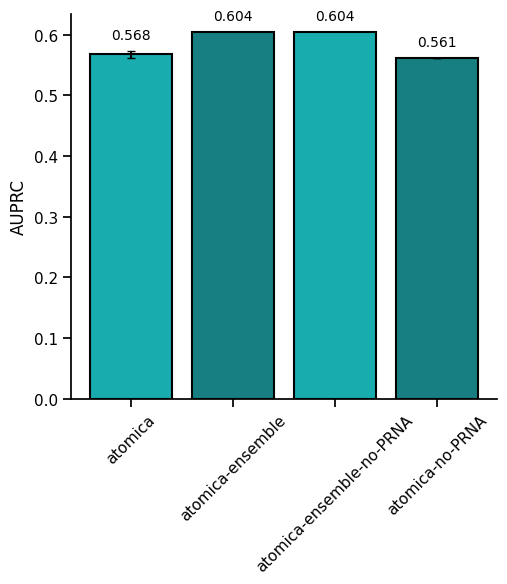

In [52]:
results = atomica_metrics.copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(5.5, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=3
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.015
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.tick_params(axis="x", labelrotation=45)
ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_protein_no_PRNA_auprc_comparison.svg", format='svg')
plt.show()

### Grouped scores by id

In [ ]:
atomica_results['pred_bin'] = ensemble_pred >= best_t

atomica_results['correct'] = atomica_results['label'] == atomica_results['pred_bin']
balanced_acc = atomica_results.groupby('id')['correct'].mean().mean()

atomica_results['baseline_correct'] = atomica_results['label'] == 0
baseline_acc = atomica_results.groupby('id')['baseline_correct'].mean().mean()

print(balanced_acc, baseline_acc)

0.6970169462442661 0.6970169462442661


In [ ]:
grouped = atomica_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.7115
Mean AUROC: 0.5000
Baseline: 0.4230


# RNA-Site (SOTA)

In [53]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie","grnade"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Site", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baselines = pd.concat([baselines, rnaglib_baselines['RNA_Site']])
baselines_ensemble = baselines[baselines['version'] == 'ensemble'].copy()
baselines_ensemble['baseline_model'] = baselines_ensemble['baseline_model'].apply(lambda x: f"{x} (ensemble)")
baseline_agg_results = baselines[baselines['version'] != 'ensemble'].groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
ensemble_agg_results = baselines_ensemble.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results = pd.concat([baseline_agg_results, ensemble_agg_results])
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                         mean       std              mean       std      mean   
baseline_model                                                                  
RNAGlib              0.889834  0.009012          0.559512  0.011144  0.608800   
grnade               0.922824  0.000000          0.500000  0.000000  0.566282   
rinalmo              0.921996  0.001323          0.508716  0.005348  0.674559   
rnaernie             0.923198  0.001054          0.509909  0.009228  0.598334   
rnafm                0.921904  0.000000          0.500000  0.000000  0.678692   
RNAGlib (ensemble)   0.896026       NaN          0.542832       NaN  0.622064   
grnade (ensemble)    0.922824       NaN          0.500000       NaN  0.568594   
rinalmo (ensemble)   0.921904       NaN          0.500000       NaN  0.687046   
rnaernie (ensemble)  0.923290       NaN          0.508876       NaN  0.604722   
rnafm (ensemble)     0.921904       NaN          0.500000       NaN  0.694135   

                                  auprc            
                          std      mean       std  
baseline_model                                     
RNAGlib              0.015353  0.135825  0.009664  
grnade               0.007953  0.108140  0.008089  
rinalmo              0.019643  0.184174  0.015031  
rnaernie             0.020064  0.167034  0.014363  
rnafm                0.013187  0.131451  0.007378  
RNAGlib (ensemble)        NaN  0.146224       NaN  
grnade (ensemble)         NaN  0.106088       NaN  
rinalmo (ensemble)        NaN  0.197257       NaN  
rnaernie (ensemble)       NaN  0.178571       NaN  
rnafm (ensemble)          NaN  0.140277       NaN

In [54]:
# Ensemble five models with the highest validation AUPRC
# model_checkpoints = [
#     f'{MODEL_DIR}/RNA_Site/models/version_57/checkpoint/epoch55_step2520.pt',
#     f'{MODEL_DIR}/RNA_Site/models/version_58/checkpoint/epoch53_step2484.pt',
#     f'{MODEL_DIR}/RNA_Site/models/version_60/checkpoint/epoch35_step1620.pt',
#     f'{MODEL_DIR}/RNA_Site/models/version_61/checkpoint/epoch52_step2544.pt',
#     f'{MODEL_DIR}/RNA_Site/models/version_59/checkpoint/epoch78_step3792.pt',
# ]

# model_checkpoints_no_RNAL = [
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Site/models/version_97/checkpoint/epoch47_step2304.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Site/models/version_94/checkpoint/epoch48_step2352.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Site/models/version_48/checkpoint/epoch38_step1872.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Site/models/version_96/checkpoint/epoch50_step2295.pt',
#     '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Site/models/version_50/checkpoint/epoch46_step2115.pt',
# ]

model_checkpoints = [
    f"{SAVED_MODEL_DIR}/rna_site/atomica/seed{seed}/model.pt" for seed in range(5)
]

model_checkpoints_no_RNAL = [
    f"{SAVED_MODEL_DIR}/rna_site/atomica_no_RNAL_in_pretrain/seed{seed}/model.pt" for seed in range(5)
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    print("Num atomica results", len(atomica_results))
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val['label'], atomica_results_val['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val['label'] == atomica_results_val['pred']),
        'roc_auc': roc_auc_score(atomica_results_val['label'], atomica_results_val['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_RNAL = None
for model_checkpoint in model_checkpoints_no_RNAL:
    atomica_results_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    if ensemble_prob_no_RNAL is None:
        ensemble_prob_no_RNAL = atomica_results_no_RNAL['pred_probability']
    else:
        ensemble_prob_no_RNAL += atomica_results_no_RNAL['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_RNAL['label'] == atomica_results_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val_no_RNAL['label'] == atomica_results_val_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)


ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_RNAL = np.stack(ensemble_prob_no_RNAL) / len(model_checkpoints_no_RNAL)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results['label'], (ensemble_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = (ensemble_prob > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_RNAL = (ensemble_prob_no_RNAL > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL)
auprc_no_RNAL = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-RNAL',
    'checkpoint_path': 'ensemble-no-RNAL',
    'accuracy': np.mean(atomica_results_no_RNAL['label'] == ensemble_pred_no_RNAL),
    'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL),
    'auprc': auprc_no_RNAL,
}
all_metrics.append(metrics_dict)


all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

Num atomica results 2158
Num atomica results 2158
Num atomica results 2158
Num atomica results 2158
Num atomica results 2158


Running inference: 100%|██████████| 34/34 [00:10<00:00,  3.33it/s]


accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.916589  0.011398  0.597837  0.032930  0.159231   
atomica-ensemble          0.920297  0.011398  0.623042  0.032930  0.219925   
atomica-ensemble-no-RNAL  0.924467       NaN  0.635529       NaN  0.212459   
atomica-no-RNAL           0.921687  0.000000  0.620164  0.015635  0.166792   
atomica-no-RNAL-val       0.921832  0.000000  0.719837  0.032257  0.291276   
atomica-val               0.920074  0.003930  0.713822  0.022210  0.261453   

                                    
                               std  
model                               
atomica                   0.030235  
atomica-ensemble          0.030235  
atomica-ensemble-no-RNAL       NaN  
atomica-no-RNAL           0.018141  
atomica-no-RNAL-val       0.036017  
atomica-val               0.028368

In [55]:
all_metrics[all_metrics['model'].isin(['atomica-no-RNAL-val'])].reset_index().sort_values(by='auprc', ascending=False)

,index,model,checkpoint_path,accuracy,roc_auc,auprc
0,11,atomica-no-RNAL-val,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921832,0.752827,0.340213
1,13,atomica-no-RNAL-val,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921832,0.710358,0.312881
2,15,atomica-no-RNAL-val,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921832,0.740317,0.288825
3,17,atomica-no-RNAL-val,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921832,0.669586,0.258443
4,19,atomica-no-RNAL-val,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921832,0.726098,0.256016


In [56]:
all_metrics[all_metrics['model']=="atomica-no-RNAL"]

,model,checkpoint_path,accuracy,roc_auc,auprc
10,atomica-no-RNAL,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921687,0.611873,0.165360
12,atomica-no-RNAL,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921687,0.631225,0.157589
14,atomica-no-RNAL,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921687,0.597852,0.142785
16,atomica-no-RNAL,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921687,0.636932,0.189272
18,atomica-no-RNAL,/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMI...,0.921687,0.622941,0.178956


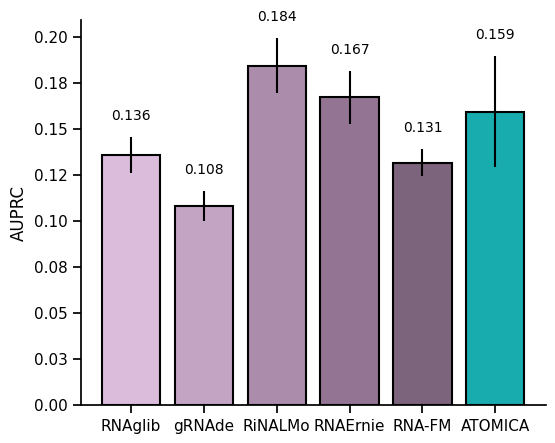

In [62]:
results = pd.concat([
    baseline_agg_results[~baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[~atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('val'))]

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=0
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.008
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}".rstrip('.')))
ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_site_auprc_comparison.svg", format='svg')
plt.show()

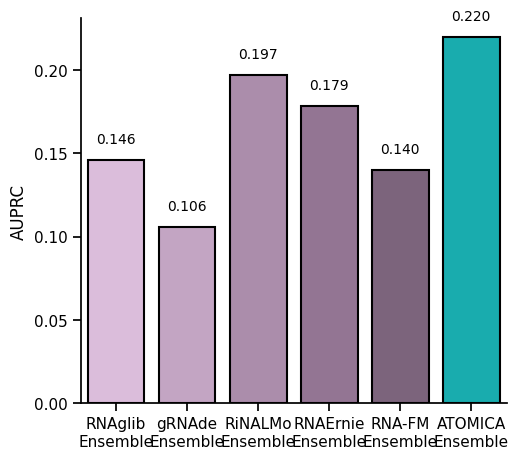

In [58]:
results = pd.concat([
    baseline_agg_results[baseline_agg_results.index.str.contains('(ensemble)')],
    atomica_metrics[atomica_metrics.index.str.contains('atomica-ensemble')],
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('val'))]

plt.figure(figsize=(5.5, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

# ax.errorbar(
#     x=x_positions,
#     y=y_means,
#     yerr=y_stds,
#     fmt='none',
#     c='black',
#     elinewidth=1.5,
#     capsize=0
# )

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + 0.008 # + (y_std if not np.isnan(y_std) else 0) 
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_site_ensemble_auprc_comparison.svg", format='svg')
plt.show()

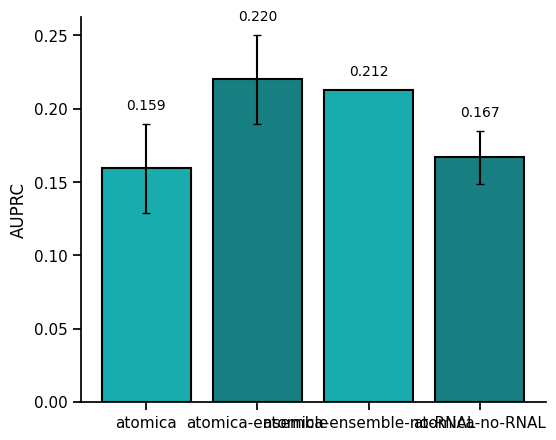

In [59]:
results = atomica_metrics[~atomica_metrics.index.str.contains('val')].copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5,
    capsize=3
)

# Add text labels on top of bars
for i, (y_mean, y_std) in enumerate(zip(y_means, y_stds)):
    y_pos = y_mean + (y_std if not np.isnan(y_std) else 0) + 0.008
    ax.text(i, y_pos, f'{y_mean:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.savefig("figures/rna_site_no_RNAL_auprc_comparison.svg", format='svg')
plt.show()

### Grouped scores by id

In [ ]:
ensemble_results = {
    'id': atomica_results['id'].apply(lambda x: "_".join(x.split('_')[0:2])),
    'pred': ensemble_pred,
    'label': atomica_results['label'],
    'pred_probability': ensemble_prob,
}
ensemble_results = pd.DataFrame(ensemble_results)
grouped = ensemble_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.4945
Mean AUROC: 0.5543
Baseline: 0.1036
